In [1]:
"""
Trade-linked livestock-related land-use-change (LUC) emissions analysis
using Singh et al. 2024 / DeDuCE trade-flow hybrid data + FAOSTAT feed-use data.

What this script does
---------------------
1. Loads Singh Trade flows-hybrid data.
2. Loads FAOSTAT crop feed-use data.
3. Harmonizes country names in both datasets.
4. Calculates livestock-related LUC emissions from:
   - pasture / ruminant meat: 100% livestock-related
   - feed crops: crop LUC emissions multiplied by FAOSTAT feed-use share
5. Preserves producer-to-consumer trade attribution:
   - results can be summarized by producer location or consumer country.
6. Exports cleaned files, checks, summaries, and figures.

Required input files should be placed in the local data/ folder beside this notebook:
- FAOSTAT_crops_feed_data.csv
- Singh et al 2024 - Commodity-driven deforestation, carbon emissions & trade 2018-2022.xlsx
"""

'\nTrade-linked livestock-related land-use-change (LUC) emissions analysis\nusing Singh et al. 2024 / DeDuCE trade-flow hybrid data + FAOSTAT feed-use data.\n\nWhat this script does\n---------------------\n1. Loads Singh Trade flows-hybrid data.\n2. Loads FAOSTAT crop feed-use data.\n3. Harmonizes country names in both datasets.\n4. Calculates livestock-related LUC emissions from:\n   - pasture / ruminant meat: 100% livestock-related\n   - feed crops: crop LUC emissions multiplied by FAOSTAT feed-use share\n5. Preserves producer-to-consumer trade attribution:\n   - results can be summarized by producer location or consumer country.\n6. Exports cleaned files, checks, summaries, and figures.\n\nRequired input files should be placed in the local data/ folder beside this notebook:\n- FAOSTAT_crops_feed_data.csv\n- Singh et al 2024 - Commodity-driven deforestation, carbon emissions & trade 2018-2022.xlsx\n'

In [2]:
from __future__ import annotations

In [3]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [4]:
warnings.filterwarnings("ignore", category=FutureWarning)

============================================================
0. USER SETTINGS
============================================================

In [5]:
DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
FIG_DIR = Path("figures")
CHECK_DIR = OUT_DIR / "checks"

for directory in [DATA_DIR, OUT_DIR, FIG_DIR, CHECK_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

In [6]:
FAO_FILE = DATA_DIR / "FAOSTAT_crops_feed_data.csv"
SINGH_FILE = DATA_DIR / "Singh et al 2024 - Commodity-driven deforestation, carbon emissions & trade 2018-2022.xlsx"
SINGH_SHEET = "Trade flows-hybrid"

In [7]:
YEARS = list(range(2018, 2023))
LATEST_YEAR = 2022
TOP_N = 20

In [8]:
# Use peat-inclusive emissions by default, matching the earlier analysis.
LUC_COL = "Deforestation emissions incl. peat drainage (MtCO2)"

============================================================
1. PLOT STYLE
============================================================

In [9]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 300,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titlepad": 12,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.30,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,
})

In [10]:
MAIN_COLOR = "#2c7fb8"
FEED_COLOR = "#31a354"
PASTURE_COLOR = "#756bb1"
SECONDARY_COLOR = "#d95f0e"
DARK_GRAY = "#4d4d4d"

============================================================
2. COUNTRY NAME HARMONIZATION
============================================================

In [11]:
# Keep canonical names simple and close to Singh/FAOSTAT names.
COUNTRY_NAME_FIX = {
    # US / UK variants
    "USA": "United States",
    "US": "United States",
    "United States of America": "United States",
    "UK": "United Kingdom",
    "Great Britain": "United Kingdom",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",

    # China variants
    "China, mainland": "China",
    "Mainland China": "China",

    # Korea variants
    "South Korea": "Republic of Korea",
    "Korea, Republic of": "Republic of Korea",

    # Common country-name variants
    "Czech Republic": "Czechia",
    "Viet Nam": "Vietnam",
    "Türkiye": "Turkey",
    "Russian Federation": "Russia",
    "Iran (Islamic Republic of)": "Iran",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Syrian Arab Republic": "Syria",
    "Lao People's Democratic Republic": "Laos",
    "Democratic Republic of the Congo": "DR Congo",
    "Congo, Dem. Rep.": "DR Congo",
    "Congo": "Republic of the Congo",
    "Congo, Rep.": "Republic of the Congo",
    "United Republic of Tanzania": "Tanzania",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Moldova, Republic of": "Moldova",
    "Brunei Darussalam": "Brunei",
}

In [12]:
def clean_country_name(x):
    """Clean and harmonize country names. Preserves RoW regional categories."""
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    x = " ".join(x.split())
    return COUNTRY_NAME_FIX.get(x, x)

In [13]:
# Optional grouping only for checks, not central to the analysis.
GLOBAL_NORTH = {
    "Australia", "Austria", "Belgium", "Bulgaria", "Canada", "Croatia", "Cyprus",
    "Czechia", "Denmark", "Estonia", "Finland", "France", "Germany", "Greece",
    "Hungary", "Iceland", "Ireland", "Israel", "Italy", "Japan", "Latvia",
    "Lithuania", "Luxembourg", "Malta", "Netherlands", "New Zealand", "Norway",
    "Poland", "Portugal", "Republic of Korea", "Romania", "Slovakia", "Slovenia",
    "Spain", "Sweden", "Switzerland", "United Kingdom", "United States",
}

In [14]:
def optional_region_group(country):
    """Optional diagnostic grouping only; NOT used for main accounting."""
    if pd.isna(country) or str(country).strip() == "":
        return "UNMAPPED"
    country = str(country).strip()
    if country == "China":
        return "China"
    if country in GLOBAL_NORTH:
        return "Global North"
    if country.startswith("RoW"):
        return "RoW aggregate"
    return "Global South / other"

============================================================
3. COMMODITY HARMONIZATION
============================================================

In [15]:
FEED_CROP_MAP = {
    "soybeans": "Soybeans", "soya beans": "Soybeans", "soyabeans": "Soybeans",
    "rapeseed": "Rapeseed", "rape or colza seed": "Rapeseed", "canola": "Rapeseed",
    "sunflower seed": "Sunflower seed", "sunflower seeds": "Sunflower seed", "sunflower": "Sunflower seed",
    "maize": "Maize", "maize (corn)": "Maize", "corn": "Maize",
    "barley": "Barley",
    "sorghum": "Sorghum",
}

In [16]:
FEED_SET = {"Soybeans", "Rapeseed", "Sunflower seed", "Maize", "Barley", "Sorghum"}
CEREAL_SET = {"Maize", "Barley", "Sorghum"}
PASTURE_SET = {"RUMINANT_MEAT"}

In [17]:
CAKE_TO_SEED = {
    "Soybean cake": "Soybeans",
    "Rapeseed cake": "Rapeseed",
    "Sunflower seed cake": "Sunflower seed",
}

In [18]:
# Cake-to-seed equivalents, following the earlier approach.
MEAL_YIELD = {
    "Soybeans": 0.80,
    "Rapeseed": 0.61,
    "Sunflower seed": 0.59,
}

In [19]:
def canon_item_fao(s):
    s0 = str(s).strip().lower().replace("  ", " ")
    if s0 in {"soybeans", "soya beans", "soyabeans"}:
        return "Soybeans"
    if s0 in {"rape or colza seed", "rapeseed"}:
        return "Rapeseed"
    if s0 in {"sunflower seed", "sunflower"}:
        return "Sunflower seed"
    if s0 in {"maize", "maize (corn)", "corn"}:
        return "Maize"
    if s0 == "barley":
        return "Barley"
    if s0 == "sorghum":
        return "Sorghum"
    if "cake of soya beans" in s0 or "soybean cake" in s0 or "cake of soybeans" in s0:
        return "Soybean cake"
    if "cake of rapeseed" in s0 or "cake of rape" in s0 or "rapeseed cake" in s0:
        return "Rapeseed cake"
    if "cake of sunflower" in s0 or "sunflower seed cake" in s0:
        return "Sunflower seed cake"
    return None

In [20]:
def canon_elem_fao(e):
    s = str(e).strip().lower()

    if s.startswith("food supply quantity") or s == "food":
        return "Food"

    if s == "feed":
        return "Feed"

    if s == "seed":
        return "Seed"

    if s == "loss":
        return "Loss"

    if s in {"other uses (non-food)", "other uses"}:
        return "Other uses"

    if s in {"processed", "processing"}:
        return "Processing"

    if s == "residuals":
        return "Residuals"

    # NEW
    if s == "tourist consumption":
        return "Tourist consumption"

    return None

In [21]:
def canon_comm_singh(s):
    t = str(s).strip().lower()
    if ("bovin" in t) or ("cattle" in t) or ("beef" in t) or ("ruminant" in t):
        return "RUMINANT_MEAT"
    return FEED_CROP_MAP.get(t, str(s).strip())

============================================================
4. LOAD FAOSTAT AND CALCULATE FEED SHARES
============================================================

In [22]:
if not FAO_FILE.exists():
    raise FileNotFoundError(f"Missing FAOSTAT file: {FAO_FILE.resolve()}")

In [23]:
fa = pd.read_csv(FAO_FILE, low_memory=False)
fa = fa.rename(columns={c: c.strip() for c in fa.columns})
cols = {c.lower(): c for c in fa.columns}

In [24]:
AREA = cols.get("area") or cols.get("country")
ITEM = cols.get("item") or cols.get("items")
ELEM = cols.get("element") or cols.get("elements")
UNIT = cols.get("unit") or cols.get("units")
YEAR = cols.get("year") or cols.get("time")
VALUE = cols.get("value") or cols.get("values")

In [25]:
missing = [k for k, v in {"AREA": AREA, "ITEM": ITEM, "ELEM": ELEM, "YEAR": YEAR, "VALUE": VALUE}.items() if v is None]
if missing:
    raise ValueError(f"Could not identify required FAOSTAT columns: {missing}. Columns: {fa.columns.tolist()}")

In [26]:
if UNIT in fa.columns:
    u = fa[UNIT].astype(str).str.strip().str.lower()
    fa = fa[u.isin({"t", "tonnes", "1000 t"}) | fa[UNIT].isna()].copy()

In [27]:
fa[YEAR] = pd.to_numeric(fa[YEAR], errors="coerce")
fa[VALUE] = pd.to_numeric(fa[VALUE], errors="coerce").fillna(0.0)
fa = fa[fa[YEAR].isin(YEARS)].copy()

In [28]:
fa["Area_clean"] = fa[AREA].apply(clean_country_name)
fa["Item_std"] = fa[ITEM].apply(canon_item_fao)
fa["Element_std"] = fa[ELEM].apply(canon_elem_fao)
fa = fa[fa["Item_std"].notna() & fa["Element_std"].notna()].copy()

In [29]:
# Denominator: total domestic uses represented in the supplied FAOSTAT file.
den = (
    fa[fa["Item_std"].isin(FEED_SET)]
    .groupby(["Area_clean", "Item_std", YEAR], as_index=False)[VALUE]
    .sum()
    .rename(columns={VALUE: "DomesticUse_total_t", YEAR: "Year", "Item_std": "Commodity_std"})
)

In [30]:
# Cereals: direct feed use.
feed_cereals = (
    fa[(fa["Item_std"].isin(CEREAL_SET)) & (fa["Element_std"].eq("Feed"))]
    .groupby(["Area_clean", "Item_std", YEAR], as_index=False)[VALUE]
    .sum()
    .rename(columns={VALUE: "Feed_t", YEAR: "Year", "Item_std": "Commodity_std"})
)

In [31]:
# Oilseeds: use cake feed converted back to seed equivalent.
feed_cakes = (
    fa[(fa["Item_std"].isin(CAKE_TO_SEED.keys())) & (fa["Element_std"].eq("Feed"))]
    .groupby(["Area_clean", "Item_std", YEAR], as_index=False)[VALUE]
    .sum()
    .rename(columns={VALUE: "Cake_Feed_t", YEAR: "Year"})
)

In [32]:
if not feed_cakes.empty:
    feed_cakes["Commodity_std"] = feed_cakes["Item_std"].map(CAKE_TO_SEED)
    feed_cakes["Feed_t"] = feed_cakes.apply(
        lambda r: r["Cake_Feed_t"] / MEAL_YIELD[r["Commodity_std"]],
        axis=1,
    )
    feed_oilseeds = feed_cakes[["Area_clean", "Commodity_std", "Year", "Feed_t"]]
else:
    feed_oilseeds = pd.DataFrame(columns=["Area_clean", "Commodity_std", "Year", "Feed_t"])

In [33]:
feed_all = pd.concat([feed_cereals, feed_oilseeds], ignore_index=True)

In [34]:
feed_share_country = den.merge(feed_all, on=["Area_clean", "Commodity_std", "Year"], how="left")
feed_share_country["Feed_t"] = feed_share_country["Feed_t"].fillna(0.0)
feed_share_country["FeedShare_country"] = np.where(
    feed_share_country["DomesticUse_total_t"] > 0,
    feed_share_country["Feed_t"] / feed_share_country["DomesticUse_total_t"],
    np.nan,
)
feed_share_country["FeedShare_country"] = feed_share_country["FeedShare_country"].clip(0, 1)

In [35]:
# Fallback 1: global weighted feed share by crop-year.
feed_share_global_year = (
    feed_share_country
    .groupby(["Commodity_std", "Year"], as_index=False)
    .agg(Feed_t=("Feed_t", "sum"), DomesticUse_total_t=("DomesticUse_total_t", "sum"))
)
feed_share_global_year["FeedShare_global_year"] = np.where(
    feed_share_global_year["DomesticUse_total_t"] > 0,
    feed_share_global_year["Feed_t"] / feed_share_global_year["DomesticUse_total_t"],
    np.nan,
).clip(0, 1)

In [36]:
# Fallback 2: global weighted feed share by crop across all years.
feed_share_global_crop = (
    feed_share_country
    .groupby("Commodity_std", as_index=False)
    .agg(Feed_t=("Feed_t", "sum"), DomesticUse_total_t=("DomesticUse_total_t", "sum"))
)
feed_share_global_crop["FeedShare_global_crop"] = np.where(
    feed_share_global_crop["DomesticUse_total_t"] > 0,
    feed_share_global_crop["Feed_t"] / feed_share_global_crop["DomesticUse_total_t"],
    np.nan,
).clip(0, 1)

In [37]:
feed_share_country.to_csv(OUT_DIR / "faostat_feed_shares_by_country_crop_year.csv", index=False)
feed_share_global_year.to_csv(OUT_DIR / "faostat_global_feed_shares_by_crop_year.csv", index=False)
feed_share_global_crop.to_csv(OUT_DIR / "faostat_global_feed_shares_by_crop.csv", index=False)

============================================================
5. LOAD SINGH TRADE-FLOW HYBRID DATA
============================================================

In [38]:
if not SINGH_FILE.exists():
    raise FileNotFoundError(f"Missing Singh file: {SINGH_FILE.resolve()}")

In [39]:
required_cols = [
    "Producer country",
    "Consumer country",
    "Year",
    "Commodity",
    LUC_COL,
]

In [40]:
singh = pd.read_excel(
    SINGH_FILE,
    sheet_name=SINGH_SHEET,
    usecols=required_cols,
    engine="openpyxl",
)

In [41]:
singh["Year"] = pd.to_numeric(singh["Year"], errors="coerce")
singh = singh[singh["Year"].isin(YEARS)].copy()

In [42]:
singh["Producer country original"] = singh["Producer country"]
singh["Consumer country original"] = singh["Consumer country"]
singh["Producer country clean"] = singh["Producer country"].apply(clean_country_name)
singh["Consumer country clean"] = singh["Consumer country"].apply(clean_country_name)

In [43]:
singh["producer_group_optional"] = singh["Producer country clean"].apply(optional_region_group)
singh["consumer_group_optional"] = singh["Consumer country clean"].apply(optional_region_group)

In [44]:
singh["Commodity_std"] = singh["Commodity"].apply(canon_comm_singh)
singh["is_feed_crop"] = singh["Commodity_std"].isin(FEED_SET)
singh["is_pasture"] = singh["Commodity_std"].isin(PASTURE_SET)
singh["LUC_MtCO2_total_commodity"] = pd.to_numeric(singh[LUC_COL], errors="coerce").fillna(0.0)

In [45]:
# Keep only livestock-related channels.
luc = singh[singh["is_feed_crop"] | singh["is_pasture"]].copy()

============================================================
6. APPLY FEED SHARE USING CONSUMER COUNTRY
============================================================

In [46]:
# Main accounting choice:
# Feed-crop emissions are multiplied by the feed-use share in the consumer country,
# preserving the producer-to-consumer attribution represented in the Singh trade-flow framework.
luc = luc.merge(
    feed_share_country[["Area_clean", "Commodity_std", "Year", "FeedShare_country"]],
    left_on=["Consumer country clean", "Commodity_std", "Year"],
    right_on=["Area_clean", "Commodity_std", "Year"],
    how="left",
)

In [47]:
luc = luc.merge(
    feed_share_global_year[["Commodity_std", "Year", "FeedShare_global_year"]],
    on=["Commodity_std", "Year"],
    how="left",
)

In [48]:
luc = luc.merge(
    feed_share_global_crop[["Commodity_std", "FeedShare_global_crop"]],
    on="Commodity_std",
    how="left",
)

In [49]:
luc["feed_share_source"] = np.select(
    [
        luc["is_pasture"],
        luc["FeedShare_country"].notna(),
        luc["FeedShare_global_year"].notna(),
        luc["FeedShare_global_crop"].notna(),
    ],
    [
        "pasture_not_applicable",
        "consumer_country_crop_year",
        "global_crop_year_fallback",
        "global_crop_all_years_fallback",
    ],
    default="missing_set_to_zero",
)

In [50]:
luc["FeedShare_used"] = (
    luc["FeedShare_country"]
    .fillna(luc["FeedShare_global_year"])
    .fillna(luc["FeedShare_global_crop"])
    .fillna(0.0)
    .clip(0, 1)
)

In [51]:
luc["component"] = np.where(luc["is_pasture"], "Pasture", "Feed")

In [52]:
luc["LUC_livestock_MtCO2"] = np.where(
    luc["is_feed_crop"],
    luc["LUC_MtCO2_total_commodity"] * luc["FeedShare_used"],
    luc["LUC_MtCO2_total_commodity"],
)

============================================================
7. COUNTRY AND FEED-SHARE CHECKS
============================================================

In [53]:
producer_country_check = (
    singh[["Producer country original", "Producer country clean", "producer_group_optional"]]
    .drop_duplicates()
    .sort_values(["producer_group_optional", "Producer country clean"])
)
consumer_country_check = (
    singh[["Consumer country original", "Consumer country clean", "consumer_group_optional"]]
    .drop_duplicates()
    .sort_values(["consumer_group_optional", "Consumer country clean"])
)

In [54]:
producer_country_check.to_csv(CHECK_DIR / "producer_country_name_check.csv", index=False)
consumer_country_check.to_csv(CHECK_DIR / "consumer_country_name_check.csv", index=False)

In [55]:
# Countries in Singh consumer data that did not get country-specific FAOSTAT feed shares.
feed_rows = luc[luc["is_feed_crop"]].copy()
missing_consumer_feedshare = (
    feed_rows[feed_rows["FeedShare_country"].isna()]
    .groupby(["Consumer country original", "Consumer country clean", "Commodity_std"], as_index=False)
    .agg(
        rows=("Commodity_std", "size"),
        LUC_before_feedshare_MtCO2=("LUC_MtCO2_total_commodity", "sum"),
    )
    .sort_values("LUC_before_feedshare_MtCO2", ascending=False)
)
missing_consumer_feedshare.to_csv(CHECK_DIR / "consumer_country_crop_missing_FAOSTAT_feedshare_used_fallback.csv", index=False)

In [56]:
feed_share_source_summary = (
    luc.groupby(["component", "feed_share_source"], as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .sort_values(["component", "LUC_livestock_MtCO2"], ascending=[True, False])
)
feed_share_source_summary.to_csv(CHECK_DIR / "feed_share_source_summary.csv", index=False)

In [57]:
# Specific check for United States.
us_check = luc[
    luc["Consumer country clean"].eq("United States") |
    luc["Producer country clean"].eq("United States") |
    luc["Consumer country original"].astype(str).str.contains("United States|USA", case=False, na=False) |
    luc["Producer country original"].astype(str).str.contains("United States|USA", case=False, na=False)
][[
    "Producer country original", "Producer country clean",
    "Consumer country original", "Consumer country clean",
    "producer_group_optional", "consumer_group_optional",
]].drop_duplicates()
us_check.to_csv(CHECK_DIR / "united_states_name_and_group_check.csv", index=False)

============================================================
8. EXPORT CLEANED FLOW-LEVEL DATA
============================================================

In [58]:
luc.to_csv(OUT_DIR / "livestock_related_LUC_consumption_based_flows_2018_2022.csv", index=False)

In [59]:
# Excel export with important sheets.
with pd.ExcelWriter(OUT_DIR / "livestock_related_LUC_consumption_based_outputs.xlsx", engine="openpyxl") as writer:
    luc.to_excel(writer, sheet_name="cleaned_flows", index=False)
    feed_share_country.to_excel(writer, sheet_name="FAOSTAT_feed_shares", index=False)
    missing_consumer_feedshare.to_excel(writer, sheet_name="feedshare_fallback_checks", index=False)
    producer_country_check.to_excel(writer, sheet_name="producer_name_check", index=False)
    consumer_country_check.to_excel(writer, sheet_name="consumer_name_check", index=False)

============================================================
9. SUMMARY TABLES: PRODUCER AND CONSUMER ATTRIBUTION
============================================================

In [60]:
def add_share(df, value_col="LUC_livestock_MtCO2"):
    df = df.copy()
    total = df[value_col].sum()
    df["share_percent"] = np.where(total > 0, df[value_col] / total * 100, 0)
    return df

In [61]:
annual_total = (
    luc.groupby("Year", as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .sort_values("Year")
)
annual_total.to_csv(OUT_DIR / "annual_total_livestock_related_LUC_emissions_consumption_based.csv", index=False)

In [62]:
annual_component = (
    luc.groupby(["Year", "component"], as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .sort_values(["Year", "component"])
)
annual_component.to_csv(OUT_DIR / "annual_feed_vs_pasture_LUC_emissions_consumption_based.csv", index=False)

In [63]:
component_total = add_share(
    luc.groupby("component", as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .sort_values("LUC_livestock_MtCO2", ascending=False)
)
component_total.to_csv(OUT_DIR / "cumulative_feed_vs_pasture_LUC_2018_2022_consumption_based.csv", index=False)

In [64]:
commodity_total = add_share(
    luc.groupby(["Commodity_std", "component"], as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .sort_values("LUC_livestock_MtCO2", ascending=False)
)
commodity_total.to_csv(OUT_DIR / "commodity_contribution_livestock_related_LUC_2018_2022_consumption_based.csv", index=False)

In [65]:
# Main country table: consumer-country responsibility.
consumer_country_total = add_share(
    luc.groupby("Consumer country clean", as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .sort_values("LUC_livestock_MtCO2", ascending=False)
    .rename(columns={"Consumer country clean": "Consumer country"})
)
consumer_country_total.to_csv(OUT_DIR / "top_consumer_countries_livestock_related_LUC_2018_2022.csv", index=False)

In [66]:
consumer_country_year = (
    luc.groupby(["Year", "Consumer country clean"], as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .rename(columns={"Consumer country clean": "Consumer country"})
    .sort_values(["Year", "LUC_livestock_MtCO2"], ascending=[True, False])
)
consumer_country_year.to_csv(OUT_DIR / "consumer_countries_livestock_related_LUC_by_year.csv", index=False)

In [67]:
# Traceability table: where the emissions physically occurred, but assigned to consumer countries.
producer_consumer_matrix = (
    luc.groupby(["Consumer country clean", "Producer country clean"], as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .rename(columns={"Consumer country clean": "Consumer country", "Producer country clean": "Producer country"})
    .sort_values("LUC_livestock_MtCO2", ascending=False)
)
producer_consumer_matrix.to_csv(OUT_DIR / "consumer_producer_matrix_livestock_related_LUC_2018_2022.csv", index=False)

In [68]:
# Producer-location table retained for interpretation only, not responsibility accounting.
producer_country_total = add_share(
    luc.groupby("Producer country clean", as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .sort_values("LUC_livestock_MtCO2", ascending=False)
    .rename(columns={"Producer country clean": "Producer country"})
)
producer_country_total.to_csv(OUT_DIR / "producer_location_livestock_related_LUC_2018_2022_not_responsibility.csv", index=False)

============================================================
10. FIGURE HELPERS
============================================================

In [69]:
def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

============================================================
11. FIGURES
============================================================

In [70]:
# 11.1 Annual total
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(annual_total["Year"], annual_total["LUC_livestock_MtCO2"], marker="o", linewidth=2.2, color=MAIN_COLOR)
for _, row in annual_total.iterrows():
    ax.text(row["Year"], row["LUC_livestock_MtCO2"], f"{row['LUC_livestock_MtCO2']:.1f}", ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Year")
ax.set_ylabel("Livestock-related LUC emissions (Mt CO$_2$)")
ax.set_title("Consumption-based livestock-related land-use-change emissions, 2018–2022")
ax.set_xticks(YEARS)
ax.set_ylim(0, annual_total["LUC_livestock_MtCO2"].max() * 1.18)
plt.tight_layout()
savefig(fig, "annual_total_livestock_related_LUC_emissions_consumption_based")
plt.close(fig)

In [71]:
# 11.2 Feed vs pasture annual stacked bars
component_wide = annual_component.pivot(index="Year", columns="component", values="LUC_livestock_MtCO2").fillna(0)
fig, ax = plt.subplots(figsize=(8.8, 5.4))
bottom = np.zeros(len(component_wide))
for comp, color in [("Feed", FEED_COLOR), ("Pasture", PASTURE_COLOR)]:
    if comp in component_wide.columns:
        vals = component_wide[comp].values
        ax.bar(component_wide.index.astype(str), vals, bottom=bottom, label=comp, color=color, edgecolor="black", linewidth=0.5)
        bottom += vals
ax.set_ylabel("Livestock-related LUC emissions (Mt CO$_2$)")
ax.set_xlabel("Year")
ax.set_title("Consumption-based feed-crop and pasture contributions to livestock-related LUC emissions")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.14), ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.92])
savefig(fig, "annual_feed_vs_pasture_LUC_emissions_consumption_based")
plt.close(fig)

In [72]:
# 11.3 Cumulative feed vs pasture
fig, ax = plt.subplots(figsize=(6.8, 5.0))
colors = [FEED_COLOR if c == "Feed" else PASTURE_COLOR for c in component_total["component"]]
ax.bar(component_total["component"], component_total["LUC_livestock_MtCO2"], color=colors, edgecolor="black", linewidth=0.5)
for i, row in enumerate(component_total.itertuples()):
    ax.text(i, row.LUC_livestock_MtCO2, f"{row.LUC_livestock_MtCO2:.1f} Mt\n({row.share_percent:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Livestock-related LUC emissions (Mt CO$_2$)")
ax.set_title("Cumulative trade-linked livestock-related LUC emissions by component, 2018–2022")
ax.set_ylim(0, component_total["LUC_livestock_MtCO2"].max() * 1.25)
plt.tight_layout()
savefig(fig, "cumulative_feed_vs_pasture_LUC_2018_2022_consumption_based")
plt.close(fig)

In [73]:
# 11.4 Commodity contribution
plot_df = commodity_total.sort_values("LUC_livestock_MtCO2").copy()

def format_share(pct):
    if pct < 0.1 and pct > 0:
        return "<0.1%"
    else:
        return f"{pct:.1f}%"

plot_df["share_label"] = plot_df["share_percent"].apply(format_share)

plot_df["label"] = (
    plot_df["Commodity_std"]
    + " ("
    + plot_df["component"]
    + ", "
    + plot_df["share_label"]
    + ")"
)

fig, ax = plt.subplots(figsize=(9.5, max(5.2, 0.42 * len(plot_df))))

bar_colors = [
    FEED_COLOR if c == "Feed" else PASTURE_COLOR
    for c in plot_df["component"]
]

ax.barh(
    plot_df["label"],
    plot_df["LUC_livestock_MtCO2"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5
)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(
        row.LUC_livestock_MtCO2,
        i,
        f" {row.LUC_livestock_MtCO2:.1f}",
        va="center",
        fontsize=10
    )

ax.set_xlabel("Livestock-related LUC emissions (Mt CO$_2$)")
ax.set_title(
    "Commodity contributions to trade-linked livestock-related LUC emissions, 2018–2022"
)
ax.set_xlim(0, plot_df["LUC_livestock_MtCO2"].max() * 1.18)

plt.tight_layout()
savefig(fig, "commodity_contribution_livestock_related_LUC_2018_2022_consumption_based")
plt.close(fig)

In [74]:
# 11.5 Top consumer countries: MAIN RESPONSIBILITY FIGURE
plot_df = consumer_country_total.head(TOP_N).sort_values("LUC_livestock_MtCO2").copy()
plot_df["label"] = plot_df["Consumer country"] + " (" + plot_df["share_percent"].round(1).astype(str) + "%)"
fig, ax = plt.subplots(figsize=(10.5, max(6.2, 0.38 * len(plot_df))))
ax.barh(plot_df["label"], plot_df["LUC_livestock_MtCO2"], color=MAIN_COLOR, edgecolor="black", linewidth=0.5)
for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.LUC_livestock_MtCO2, i, f" {row.LUC_livestock_MtCO2:.1f}", va="center", fontsize=10)
ax.set_xlabel("Livestock-related LUC emissions attributed to consumers (Mt CO$_2$)")
ax.set_title(f"Top {TOP_N} consumer countries responsible for livestock-related LUC emissions, 2018–2022")
ax.set_xlim(0, plot_df["LUC_livestock_MtCO2"].max() * 1.18)
plt.tight_layout()
savefig(fig, "top_consumer_countries_livestock_related_LUC_2018_2022")
plt.close(fig)

In [75]:
# 11.6 Producer-location figure retained only as supplementary traceability
plot_df = producer_country_total.head(TOP_N).sort_values("LUC_livestock_MtCO2").copy()
plot_df["label"] = (
    plot_df["Producer country"]
    + " ("
    + plot_df["share_percent"].round(1).astype(str)
    + "%)"
)

fig, ax = plt.subplots(figsize=(11.5, max(7.0, 0.45 * len(plot_df))))

ax.barh(
    plot_df["label"],
    plot_df["LUC_livestock_MtCO2"],
    color=SECONDARY_COLOR,
    edgecolor="black",
    linewidth=0.5
)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(
        row.LUC_livestock_MtCO2,
        i,
        f" {row.LUC_livestock_MtCO2:.1f}",
        va="center",
        fontsize=11
    )

ax.set_xlabel(
    "Livestock-related LUC emissions physically occurring in producer country (Mt CO$_2$)",
    fontsize=13
)

ax.set_title(
    f"Top {TOP_N} producer locations of livestock-related LUC emissions, 2018–2022",
    fontsize=15,
    pad=12
)

ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=11)

ax.set_xlim(0, plot_df["LUC_livestock_MtCO2"].max() * 1.20)

plt.tight_layout()
savefig(fig, "top_producer_locations_livestock_related_LUC_2018_2022_supplementary")
plt.close(fig)

### Top international consumers of Brazil-produced livestock-related LUC

This figure isolates flows where the producer country is Brazil and the consumer country is outside Brazil. It therefore identifies the main external consumer economies associated with Brazil-produced livestock-related land-use-change emissions.


In [76]:
# 11.7 Top international consumers of Brazil-produced livestock-related LUC
# This figure is different from the global consumer-responsibility figure.
# It filters the producer location to Brazil and excludes domestic Brazil -> Brazil flows.

BRAZIL_TOP_N = 15

brazil_total_produced_luc = (
    luc.loc[luc["Producer country clean"].eq("Brazil"), "LUC_livestock_MtCO2"]
    .sum()
)

brazil_international_consumers = (
    luc[
        luc["Producer country clean"].eq("Brazil")
        & ~luc["Consumer country clean"].eq("Brazil")
    ]
    .groupby("Consumer country clean", as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .rename(columns={"Consumer country clean": "Consumer country"})
    .sort_values("LUC_livestock_MtCO2", ascending=False)
)

brazil_international_consumers["share_of_brazil_produced_LUC_percent"] = (
    100
    * brazil_international_consumers["LUC_livestock_MtCO2"]
    / brazil_total_produced_luc
)

brazil_international_consumers.to_csv(
    OUT_DIR / "top_international_consumers_of_Brazil_livestock_LUC_2018_2022.csv",
    index=False
)

plot_df = (
    brazil_international_consumers
    .head(BRAZIL_TOP_N)
    .sort_values("LUC_livestock_MtCO2")
    .copy()
)

fig, ax = plt.subplots(figsize=(11.5, max(6.2, 0.45 * len(plot_df))))

ax.barh(
    plot_df["Consumer country"],
    plot_df["LUC_livestock_MtCO2"],
    color=MAIN_COLOR,
    edgecolor="black",
    linewidth=0.5
)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(
        row.LUC_livestock_MtCO2,
        i,
        f" {row.LUC_livestock_MtCO2:.1f} Mt ({row.share_of_brazil_produced_LUC_percent:.1f}%)",
        va="center",
        fontsize=11
    )

ax.set_xlabel(
    "Brazil-produced livestock-related LUC consumed abroad (Mt CO$_2$), 2018–2022",
    fontsize=13
)

ax.set_title(
    "Top international consumers of Brazil-produced livestock-related LUC,\n2018–2022",
    fontsize=15,
    pad=12
)

ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=11)
ax.set_xlim(0, plot_df["LUC_livestock_MtCO2"].max() * 1.22)

plt.tight_layout()
savefig(fig, "top_international_consumers_of_Brazil_livestock_LUC_2018_2022")
plt.close(fig)

print("Top international consumers of Brazil-produced livestock-related LUC:")
print(brazil_international_consumers.head(BRAZIL_TOP_N).to_string(index=False))


Top international consumers of Brazil-produced livestock-related LUC:
    Consumer country  LUC_livestock_MtCO2  share_of_brazil_produced_LUC_percent
               China           318.054620                              7.220291
     RoW Middle East           178.111898                              4.043393
         RoW America           123.143028                              2.795521
RoW Asia and Pacific           108.715437                              2.467995
       United States            68.204825                              1.548346
          RoW Africa            33.978795                              0.771367
              Taiwan            26.251695                              0.595951
               Italy            23.197350                              0.526613
             Germany            22.379344                              0.508043
               Japan            16.781966                              0.380974
   UK and RoW Europe            15.262982         

============================================================
12. PRINT IMPORTANT RESULTS
============================================================

In [77]:
total = luc["LUC_livestock_MtCO2"].sum()
print("\nDONE: trade-linked livestock-related LUC analysis")
print("=" * 70)
print(f"Total livestock-related LUC emissions, 2018–2022: {total:,.1f} Mt CO$_2$")
print("\nComponent totals:")
print(component_total.to_string(index=False))
print("\nTop consumer countries, 2018–2022:")
print(consumer_country_total.head(15).to_string(index=False))
print("\nFeed-share fallback summary:")
print(feed_share_source_summary.to_string(index=False))
print("\nOutputs saved to:", OUT_DIR.resolve())
print("Figures saved to:", FIG_DIR.resolve())
print("Country/name checks saved to:", CHECK_DIR.resolve())


DONE: trade-linked livestock-related LUC analysis
Total livestock-related LUC emissions, 2018–2022: 7,543.4 Mt CO$_2$

Component totals:
component  LUC_livestock_MtCO2  share_percent
  Pasture          6602.570339      87.527647
     Feed           940.840893      12.472353

Top consumer countries, 2018–2022:
    Consumer country  LUC_livestock_MtCO2  share_percent
              Brazil          3363.472174      44.588212
         RoW America          1086.036680      14.397156
          RoW Africa           866.804865      11.490887
               China           480.969329       6.376019
RoW Asia and Pacific           375.592593       4.979081
       United States           244.109982       3.236069
     RoW Middle East           230.924085       3.061269
           Indonesia           121.163406       1.606215
              México            87.292835       1.157206
               India            66.461128       0.881049
              Russia            60.760837       0.805482
    

In [78]:
# Brazil responsibility diagnostic
brazil_consumer_trace = (
    luc[luc["Consumer country clean"] == "Brazil"]
    .groupby(["Producer country clean", "Commodity_std", "component"], as_index=False)
    ["LUC_livestock_MtCO2"]
    .sum()
    .sort_values("LUC_livestock_MtCO2", ascending=False)
)

brazil_consumer_trace["share_of_brazil_consumption_percent"] = (
    brazil_consumer_trace["LUC_livestock_MtCO2"]
    / brazil_consumer_trace["LUC_livestock_MtCO2"].sum()
    * 100
)

display(brazil_consumer_trace.head(20))

brazil_consumer_trace.to_csv(
    OUT_DIR / "diagnostic_brazil_consumer_responsibility_by_producer_and_component.csv",
    index=False
)

,Producer country clean,Commodity_std,component,LUC_livestock_MtCO2,share_of_brazil_consumption_percent
33,Brazil,RUMINANT_MEAT,Pasture,3266.941140,97.130018
32,Brazil,Maize,Feed,38.508308,1.144897
35,Brazil,Soybeans,Feed,20.734468,0.616460
34,Brazil,Sorghum,Feed,13.464348,0.400311
70,Colombia,RUMINANT_MEAT,Pasture,3.252720,0.096707
201,Paraguay,RUMINANT_MEAT,Pasture,3.002123,0.089257
26,Bolivia,RUMINANT_MEAT,Pasture,2.676567,0.079578
27,Bolivia,Sorghum,Feed,1.847537,0.054929
207,Peru,RUMINANT_MEAT,Pasture,1.575891,0.046853
200,Paraguay,Maize,Feed,1.052688,0.031298


In [79]:
# Brazil-produced emissions: where are they consumed?
brazil_producer_trace = (
    luc[luc["Producer country clean"] == "Brazil"]
    .groupby(["Consumer country clean", "Commodity_std", "component"], as_index=False)
    ["LUC_livestock_MtCO2"]
    .sum()
    .sort_values("LUC_livestock_MtCO2", ascending=False)
)

brazil_producer_trace["share_of_brazil_production_percent"] = (
    brazil_producer_trace["LUC_livestock_MtCO2"]
    / brazil_producer_trace["LUC_livestock_MtCO2"].sum()
    * 100
)

display(brazil_producer_trace.head(30))

brazil_producer_trace.to_csv(
    OUT_DIR / "diagnostic_brazil_produced_LUC_by_consumer.csv",
    index=False
)

,Consumer country clean,Commodity_std,component,LUC_livestock_MtCO2,share_of_brazil_production_percent
19,Brazil,RUMINANT_MEAT,Pasture,3266.941140,74.164200
35,China,RUMINANT_MEAT,Pasture,236.498312,5.368847
182,RoW Middle East,RUMINANT_MEAT,Pasture,167.519182,3.802923
170,RoW America,RUMINANT_MEAT,Pasture,116.267684,2.639441
176,RoW Asia and Pacific,RUMINANT_MEAT,Pasture,95.550668,2.169136
37,China,Soybeans,Feed,77.226361,1.753148
248,United States,RUMINANT_MEAT,Pasture,59.000245,1.339389
18,Brazil,Maize,Feed,38.508308,0.874193
164,RoW Africa,RUMINANT_MEAT,Pasture,29.102383,0.660665
230,Taiwan,RUMINANT_MEAT,Pasture,24.106799,0.547259


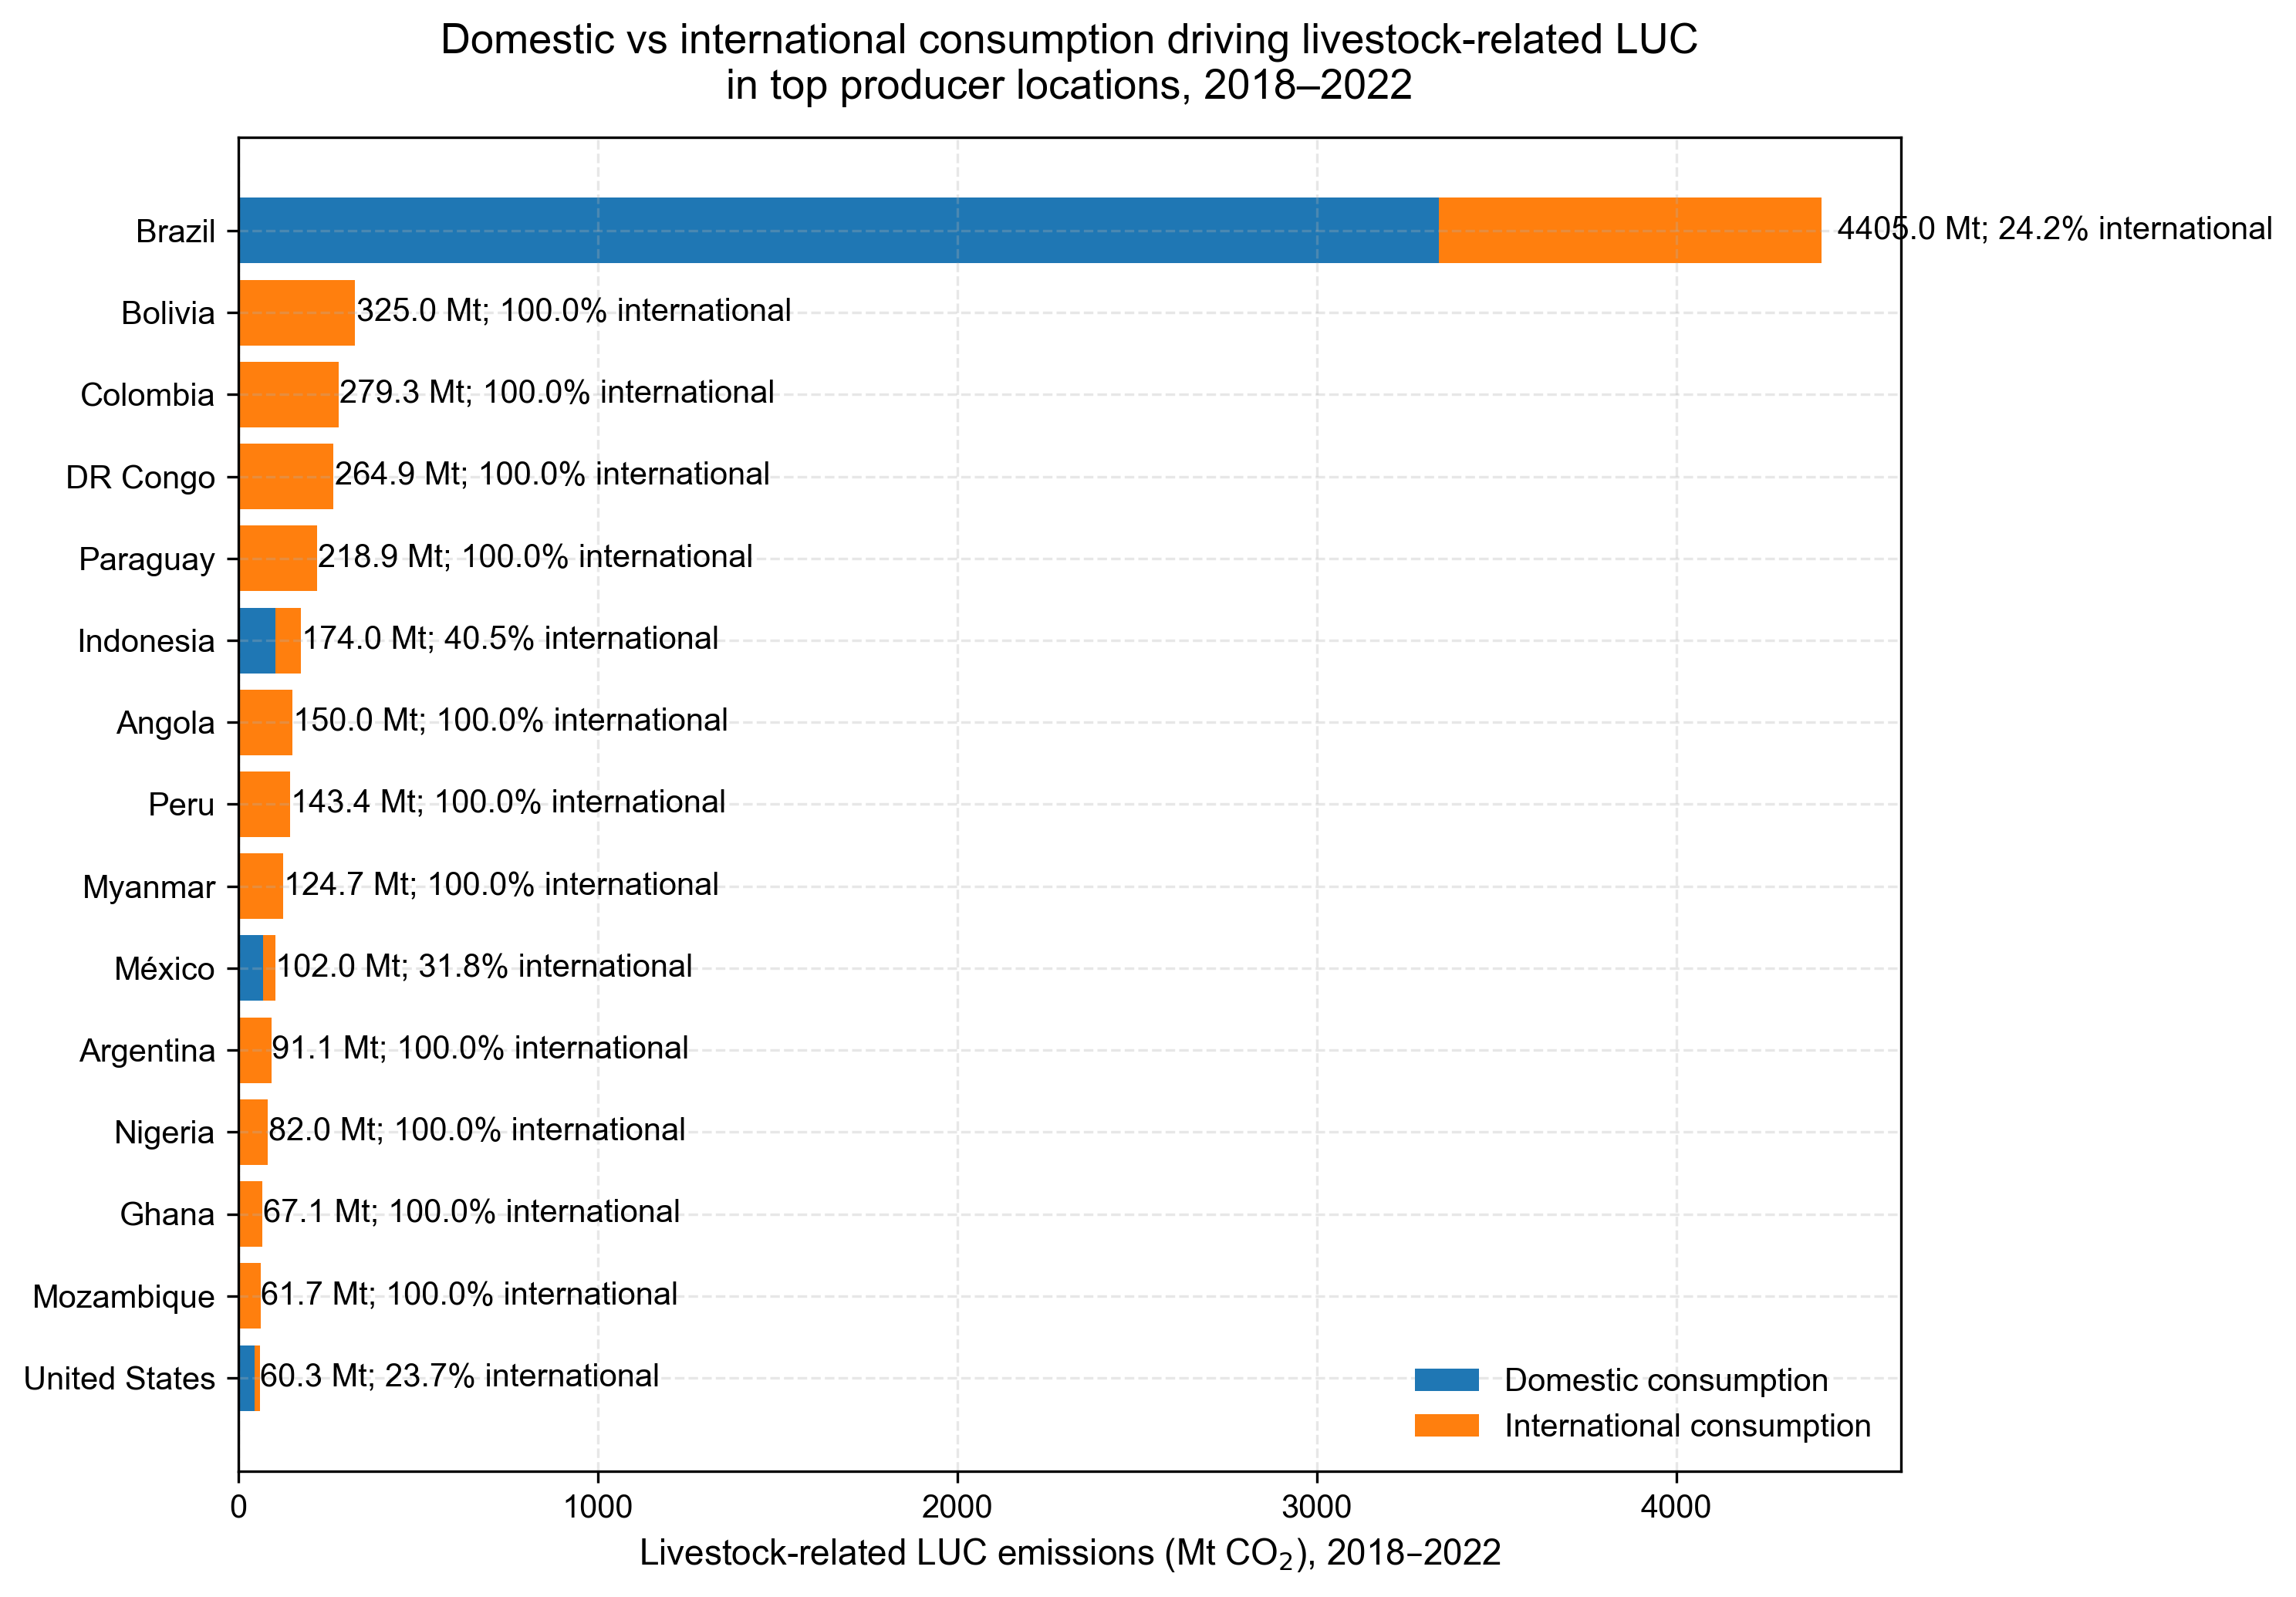

Brazil-produced livestock-related LUC, 2018–2022
Total: 4405.0 Mt CO$_2$
Domestic consumption: 3340.5 Mt CO$_2$ (75.8%)
International consumption: 1064.5 Mt CO$_2$ (24.2%)


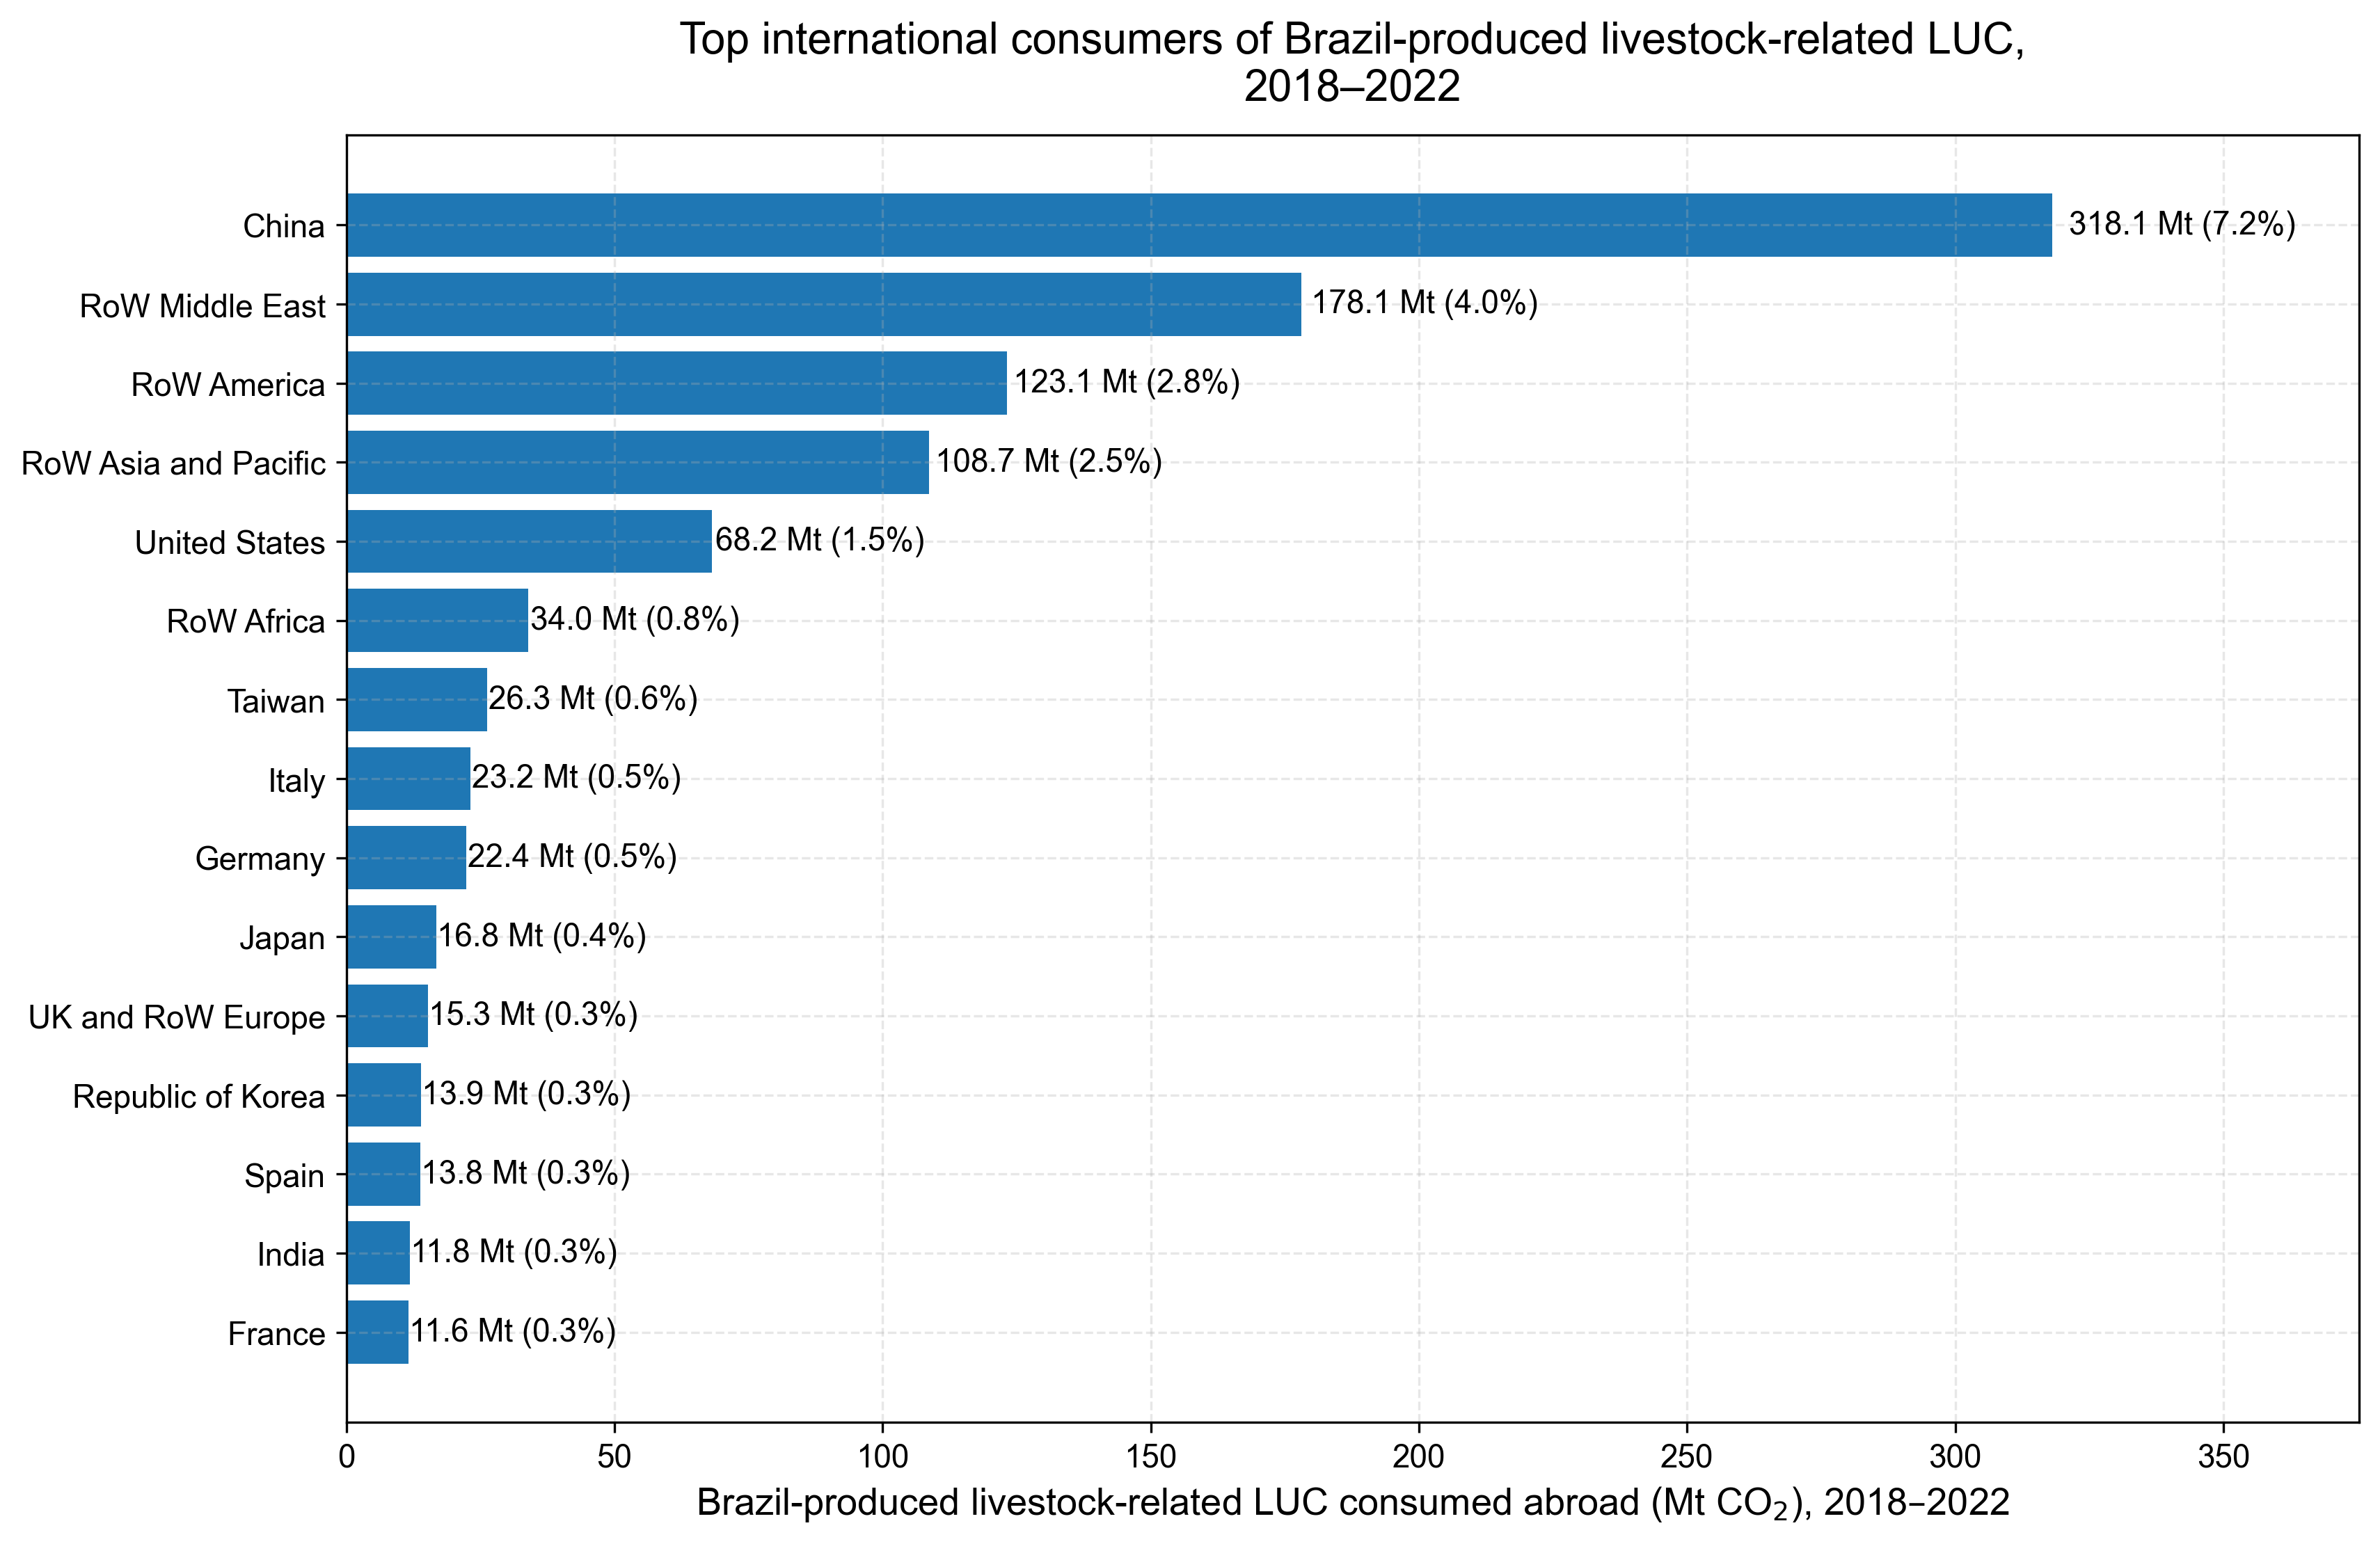

In [80]:
# ============================================================
# Domestic vs international consumer attribution of LUC
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Make sure output folders exist
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Classify each flow as domestic or international
# ------------------------------------------------------------

luc["flow_type"] = np.where(
    luc["Producer country clean"] == luc["Consumer country clean"],
    "Domestic consumption",
    "International consumption"
)

# ------------------------------------------------------------
# 2. Domestic vs international by producer location
# ------------------------------------------------------------

producer_domestic_export = (
    luc.groupby(["Producer country clean", "flow_type"], as_index=False)["LUC_livestock_MtCO2"]
    .sum()
)

producer_pivot = (
    producer_domestic_export
    .pivot(index="Producer country clean", columns="flow_type", values="LUC_livestock_MtCO2")
    .fillna(0)
)

for col in ["Domestic consumption", "International consumption"]:
    if col not in producer_pivot.columns:
        producer_pivot[col] = 0

producer_pivot["Total"] = (
    producer_pivot["Domestic consumption"]
    + producer_pivot["International consumption"]
)

producer_pivot["Domestic share (%)"] = (
    producer_pivot["Domestic consumption"] / producer_pivot["Total"] * 100
)

producer_pivot["International share (%)"] = (
    producer_pivot["International consumption"] / producer_pivot["Total"] * 100
)

producer_pivot = producer_pivot.sort_values("Total", ascending=False)

producer_pivot.to_csv(
    OUT_DIR / "domestic_vs_international_LUC_by_producer_country_2018_2022.csv"
)

# ------------------------------------------------------------
# 3. Plot top producer locations: domestic vs international
# ------------------------------------------------------------

top_n = 15
plot_df = producer_pivot.head(top_n).sort_values("Total", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_df.index,
    plot_df["Domestic consumption"],
    label="Domestic consumption"
)

ax.barh(
    plot_df.index,
    plot_df["International consumption"],
    left=plot_df["Domestic consumption"],
    label="International consumption"
)

ax.set_xlabel("Livestock-related LUC emissions (Mt CO$_2$), 2018–2022")
ax.set_ylabel("")
ax.set_title(
    "Domestic vs international consumption driving livestock-related LUC\n"
    "in top producer locations, 2018–2022"
)

ax.legend(loc="lower right")

# Add labels
for i, (country, row) in enumerate(plot_df.iterrows()):
    total = row["Total"]
    intl_share = row["International share (%)"]
    ax.text(
        total * 1.01,
        i,
        f"{total:.1f} Mt; {intl_share:.1f}% international",
        va="center",
        fontsize=10
    )

plt.tight_layout()

fig.savefig(
    FIG_DIR / "domestic_vs_international_LUC_top_producer_locations_2018_2022.pdf",
    bbox_inches="tight"
)

fig.savefig(
    FIG_DIR / "domestic_vs_international_LUC_top_producer_locations_2018_2022.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. NEW FIGURE: Top international consumers of Brazil LUC
# ============================================================

brazil_exports = luc[
    (luc["Producer country clean"] == "Brazil")
    & (luc["Consumer country clean"] != "Brazil")
].copy()

brazil_exports_by_consumer = (
    brazil_exports
    .groupby("Consumer country clean", as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .sort_values("LUC_livestock_MtCO2", ascending=False)
)

brazil_total_produced = luc.loc[
    luc["Producer country clean"] == "Brazil",
    "LUC_livestock_MtCO2"
].sum()

brazil_exports_by_consumer["Share of Brazil-produced livestock LUC (%)"] = (
    brazil_exports_by_consumer["LUC_livestock_MtCO2"]
    / brazil_total_produced
    * 100
)

brazil_exports_by_consumer.to_csv(
    OUT_DIR / "top_international_consumers_of_Brazil_livestock_LUC_2018_2022.csv",
    index=False
)

top_brazil = brazil_exports_by_consumer.head(15).sort_values(
    "LUC_livestock_MtCO2",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11.5, 7.5))

ax.barh(
    top_brazil["Consumer country clean"],
    top_brazil["LUC_livestock_MtCO2"]
)

ax.set_xlabel(
    "Brazil-produced livestock-related LUC consumed abroad (Mt CO$_2$), 2018–2022",
    fontsize=13
)
ax.set_ylabel("")
ax.set_title(
    "Top international consumers of Brazil-produced livestock-related LUC,\n"
    "2018–2022",
    fontsize=15,
    pad=12
)

ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=11)

ax.set_xlim(0, top_brazil["LUC_livestock_MtCO2"].max() * 1.18)

for i, row in enumerate(top_brazil.itertuples(index=False)):
    value = row.LUC_livestock_MtCO2
    share = row._2
    ax.text(
        value * 1.01,
        i,
        f"{value:.1f} Mt ({share:.1f}%)",
        va="center",
        fontsize=11
    )

plt.tight_layout()

# ============================================================
# 5. Print Brazil domestic/export summary
# ============================================================

brazil_domestic = luc.loc[
    (luc["Producer country clean"] == "Brazil")
    & (luc["Consumer country clean"] == "Brazil"),
    "LUC_livestock_MtCO2"
].sum()

brazil_international = luc.loc[
    (luc["Producer country clean"] == "Brazil")
    & (luc["Consumer country clean"] != "Brazil"),
    "LUC_livestock_MtCO2"
].sum()

print("Brazil-produced livestock-related LUC, 2018–2022")
print(f"Total: {brazil_total_produced:.1f} Mt CO$_2$")
print(f"Domestic consumption: {brazil_domestic:.1f} Mt CO$_2$ ({brazil_domestic / brazil_total_produced * 100:.1f}%)")
print(f"International consumption: {brazil_international:.1f} Mt CO$_2$ ({brazil_international / brazil_total_produced * 100:.1f}%)")

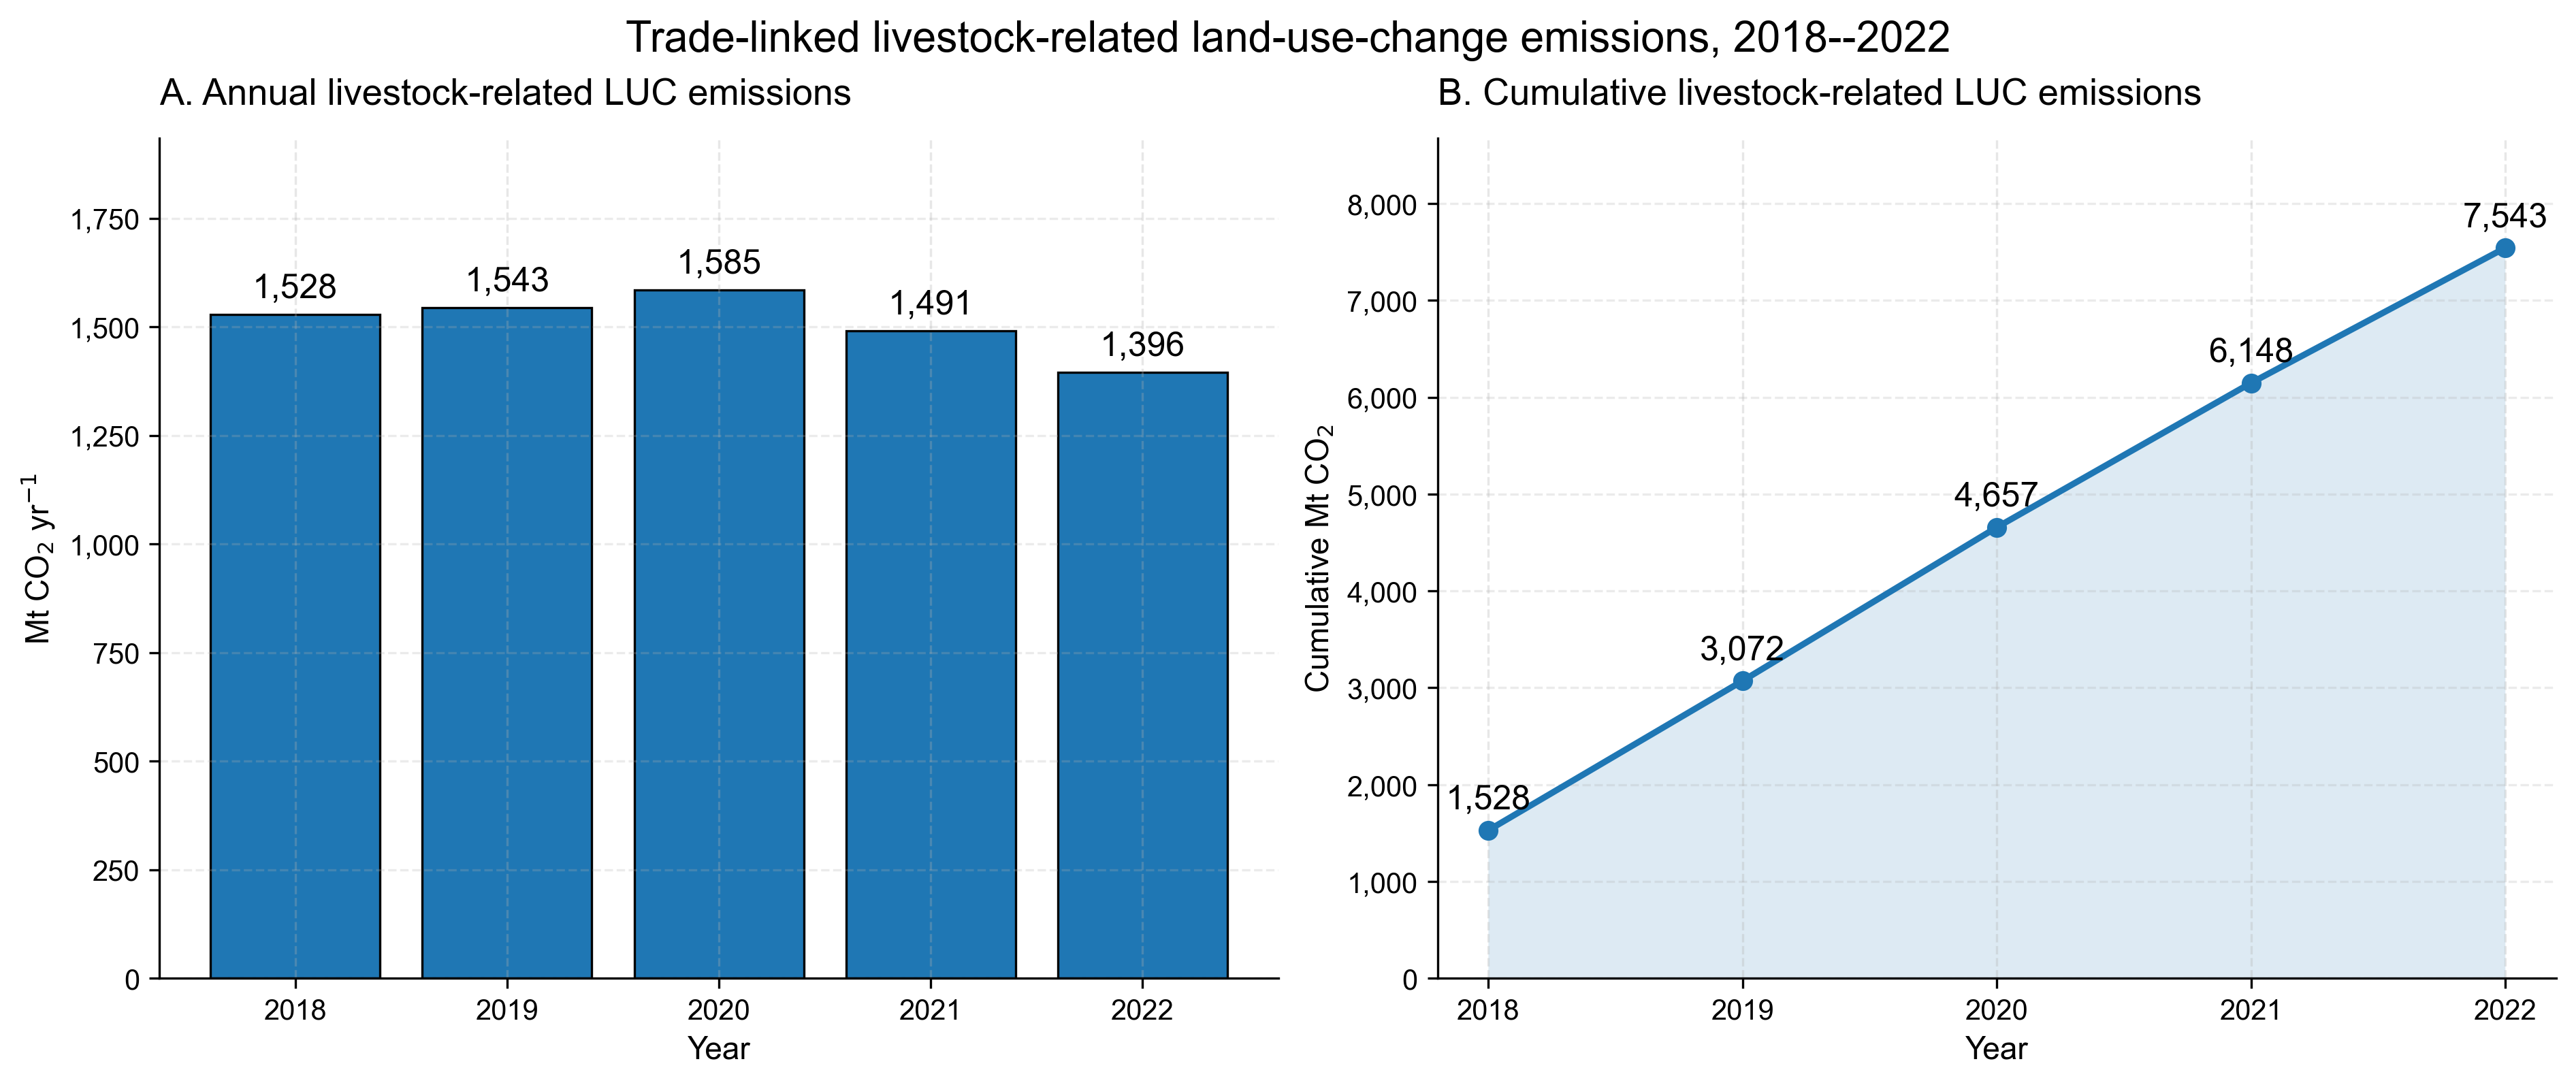

In [81]:
# ============================================================
# Two-panel figure: annual and cumulative livestock-related LUC
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

annual_luc = (
    luc.groupby("Year", as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .sort_values("Year")
)

annual_luc["Cumulative_LUC_MtCO2"] = annual_luc["LUC_livestock_MtCO2"].cumsum()

annual_luc.to_csv(
    OUT_DIR / "annual_and_cumulative_livestock_related_LUC_2018_2022.csv",
    index=False
)

# Summary values
total_cumulative = annual_luc["Cumulative_LUC_MtCO2"].iloc[-1]
peak_row = annual_luc.loc[annual_luc["LUC_livestock_MtCO2"].idxmax()]
peak_year = int(peak_row["Year"])
peak_value = peak_row["LUC_livestock_MtCO2"]

fig, axes = plt.subplots(
    1, 2,
    figsize=(12.5, 5.2),
    constrained_layout=True
)

# ------------------------------------------------------------
# Panel A: Annual emissions
# ------------------------------------------------------------
ax = axes[0]

bars = ax.bar(
    annual_luc["Year"],
    annual_luc["LUC_livestock_MtCO2"],
    edgecolor="black",
    linewidth=0.8
)

ax.set_title("A. Annual livestock-related LUC emissions", loc="left")
ax.set_xlabel("Year")
ax.set_ylabel("Mt CO$_2$ yr$^{-1}$")
ax.set_xticks(annual_luc["Year"])
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

# Value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + annual_luc["LUC_livestock_MtCO2"].max() * 0.015,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=12
    )



ax.set_ylim(0, annual_luc["LUC_livestock_MtCO2"].max() * 1.22)

# ------------------------------------------------------------
# Panel B: Cumulative emissions
# ------------------------------------------------------------
ax = axes[1]

ax.plot(
    annual_luc["Year"],
    annual_luc["Cumulative_LUC_MtCO2"],
    marker="o",
    linewidth=2.2
)

ax.fill_between(
    annual_luc["Year"],
    annual_luc["Cumulative_LUC_MtCO2"],
    alpha=0.15
)

ax.set_title("B. Cumulative livestock-related LUC emissions", loc="left")
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative Mt CO$_2$")
ax.set_xticks(annual_luc["Year"])
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

# Value labels
for x, y in zip(annual_luc["Year"], annual_luc["Cumulative_LUC_MtCO2"]):
    ax.text(
        x,
        y + total_cumulative * 0.02,
        f"{y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=12
    )



ax.set_ylim(0, total_cumulative * 1.15)

fig.suptitle(
    "Trade-linked livestock-related land-use-change emissions, 2018--2022",
    fontsize=15,
)

fig.savefig(
    FIG_DIR / "annual_and_cumulative_livestock_related_LUC_consumption_based_2018_2022.pdf",
    bbox_inches="tight"
)

fig.savefig(
    FIG_DIR / "annual_and_cumulative_livestock_related_LUC_consumption_based_2018_2022.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
# ============================================================
# Check Brazil -> Brazil rows in Singh trade-flow data
# ============================================================

brazil_domestic_rows = luc[
    (luc["Producer country clean"] == "Brazil") &
    (luc["Consumer country clean"] == "Brazil")
].copy()

print("Brazil -> Brazil rows:", len(brazil_domestic_rows))
print("Total Brazil -> Brazil LUC:",
      brazil_domestic_rows["LUC_livestock_MtCO2"].sum())

# Show available columns
print(brazil_domestic_rows.columns.tolist())

# Inspect first rows
display(
    brazil_domestic_rows.head(20)
)

# Summarize by commodity
brazil_domestic_by_commodity = (
    brazil_domestic_rows
    .groupby("Commodity", as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .sort_values("LUC_livestock_MtCO2", ascending=False)
)

display(brazil_domestic_by_commodity)

# Compare Brazil domestic vs international
brazil_all = luc[luc["Producer country clean"] == "Brazil"].copy()

brazil_split = (
    brazil_all
    .assign(
        attribution_type=lambda d: np.where(
            d["Consumer country clean"] == "Brazil",
            "Brazil-attributed",
            "External-consumer-attributed"
        )
    )
    .groupby("attribution_type", as_index=False)["LUC_livestock_MtCO2"]
    .sum()
)

brazil_split["share_percent"] = (
    100 * brazil_split["LUC_livestock_MtCO2"] /
    brazil_split["LUC_livestock_MtCO2"].sum()
)

display(brazil_split)

Brazil -> Brazil rows: 30
Total Brazil -> Brazil LUC: 3340.4652547710766
['Producer country', 'Year', 'Commodity', 'Consumer country', 'Deforestation emissions incl. peat drainage (MtCO2)', 'Producer country original', 'Consumer country original', 'Producer country clean', 'Consumer country clean', 'producer_group_optional', 'consumer_group_optional', 'Commodity_std', 'is_feed_crop', 'is_pasture', 'LUC_MtCO2_total_commodity', 'Area_clean', 'FeedShare_country', 'FeedShare_global_year', 'FeedShare_global_crop', 'feed_share_source', 'FeedShare_used', 'component', 'LUC_livestock_MtCO2', 'flow_type']


,Producer country,Year,Commodity,Consumer country,Deforestation emissions incl. peat drainage (MtCO2),Producer country original,Consumer country original,Producer country clean,Consumer country clean,producer_group_optional,...,LUC_MtCO2_total_commodity,Area_clean,FeedShare_country,FeedShare_global_year,FeedShare_global_crop,feed_share_source,FeedShare_used,component,LUC_livestock_MtCO2,flow_type
6251,Brazil,2018,Barley,Brazil,0.128402,Brazil,Brazil,Brazil,Brazil,Global South / other,...,0.128402,Brazil,0.082529,0.544498,0.550654,consumer_country_crop_year,0.082529,Feed,0.010597,Domestic consumption
6279,Brazil,2019,Barley,Brazil,0.126939,Brazil,Brazil,Brazil,Brazil,Global South / other,...,0.126939,Brazil,0.028016,0.582190,0.550654,consumer_country_crop_year,0.028016,Feed,0.003556,Domestic consumption
6306,Brazil,2020,Barley,Brazil,0.133188,Brazil,Brazil,Brazil,Brazil,Global South / other,...,0.133188,Brazil,0.070670,0.553731,0.550654,consumer_country_crop_year,0.070670,Feed,0.009412,Domestic consumption
6334,Brazil,2021,Barley,Brazil,0.130520,Brazil,Brazil,Brazil,Brazil,Global South / other,...,0.130520,Brazil,0.061311,0.517501,0.550654,consumer_country_crop_year,0.061311,Feed,0.008002,Domestic consumption
6362,Brazil,2022,Barley,Brazil,0.099311,Brazil,Brazil,Brazil,Brazil,Global South / other,...,0.099311,Brazil,0.053552,0.554141,0.550654,consumer_country_crop_year,0.053552,Feed,0.005318,Domestic consumption
6386,Brazil,2018,Maize (corn),Brazil,3.284188,Brazil,Brazil,Brazil,Brazil,Global South / other,...,3.284188,Brazil,0.766164,0.605958,0.614995,consumer_country_crop_year,0.766164,Feed,2.516227,Domestic consumption
6434,Brazil,2019,Maize (corn),Brazil,3.403254,Brazil,Brazil,Brazil,Brazil,Global South / other,...,3.403254,Brazil,0.738868,0.614426,0.614995,consumer_country_crop_year,0.738868,Feed,2.514556,Domestic consumption
6482,Brazil,2020,Maize (corn),Brazil,5.859722,Brazil,Brazil,Brazil,Brazil,Global South / other,...,5.859722,Brazil,0.758602,0.609097,0.614995,consumer_country_crop_year,0.758602,Feed,4.445197,Domestic consumption
6530,Brazil,2021,Maize (corn),Brazil,8.424140,Brazil,Brazil,Brazil,Brazil,Global South / other,...,8.424140,Brazil,0.776832,0.613896,0.614995,consumer_country_crop_year,0.776832,Feed,6.544143,Domestic consumption
6578,Brazil,2022,Maize (corn),Brazil,30.250665,Brazil,Brazil,Brazil,Brazil,Global South / other,...,30.250665,Brazil,0.743395,0.630931,0.614995,consumer_country_crop_year,0.743395,Feed,22.488185,Domestic consumption


,Commodity,LUC_livestock_MtCO2
1,"Cattle and buffalo meat, plus associated co-pr...",3266.941140
2,Maize (corn),38.508308
4,Soya beans,20.734468
3,Sorghum,13.464348
5,Sunflower seed,0.780103
0,Barley,0.036886


,attribution_type,LUC_livestock_MtCO2,share_percent
0,Brazil-attributed,3340.465255,75.833302
1,External-consumer-attributed,1064.545714,24.166698


In [83]:
brazil_domestic_rows.to_csv(
    OUT_DIR / "check_brazil_producer_brazil_consumer_rows.csv",
    index=False
)

brazil_domestic_by_commodity.to_csv(
    OUT_DIR / "check_brazil_brazil_LUC_by_commodity.csv",
    index=False
)

brazil_split.to_csv(
    OUT_DIR / "check_brazil_domestic_vs_external_attribution.csv",
    index=False
)

In [84]:
# Inspect Brazil -> Brazil by commodity
brazil_domestic_by_commodity = (
    brazil_domestic_rows
    .groupby("Commodity", as_index=False)["LUC_livestock_MtCO2"]
    .sum()
    .sort_values("LUC_livestock_MtCO2", ascending=False)
)

display(brazil_domestic_by_commodity)

,Commodity,LUC_livestock_MtCO2
1,"Cattle and buffalo meat, plus associated co-pr...",3266.941140
2,Maize (corn),38.508308
4,Soya beans,20.734468
3,Sorghum,13.464348
5,Sunflower seed,0.780103
0,Barley,0.036886


In [85]:
display(
    brazil_domestic_rows[
        [
            "Producer country clean",
            "Consumer country clean",
            "Commodity",
            "LUC_livestock_MtCO2"
        ]
    ].head(30)
)

,Producer country clean,Consumer country clean,Commodity,LUC_livestock_MtCO2
6251,Brazil,Brazil,Barley,0.010597
6279,Brazil,Brazil,Barley,0.003556
6306,Brazil,Brazil,Barley,0.009412
6334,Brazil,Brazil,Barley,0.008002
6362,Brazil,Brazil,Barley,0.005318
6386,Brazil,Brazil,Maize (corn),2.516227
6434,Brazil,Brazil,Maize (corn),2.514556
6482,Brazil,Brazil,Maize (corn),4.445197
6530,Brazil,Brazil,Maize (corn),6.544143
6578,Brazil,Brazil,Maize (corn),22.488185
